In [ ]:
import numpy as np
import pandas as pd
from statsmodels.stats.contingency_tables import mcnemar

In [ ]:
# The result from Gite's model trained with balanced data
gite_data = pd.read_csv('result_Gite_balancedData_ms_today_.csv')
case_data = pd.read_csv('Result_CaseModel_rvNeutral.csv')

In [ ]:
# 1. Preparation of prediction results (Gite: preprocessed (balanced), Case: preprocessed)
# Actual value
y_true = gite_data['ActualValue']

# Prediction results of Gite's Model
y_pred_model1 = gite_data['preprocessed_ms_today']

# Prediction results of Case's Model
y_pred_model2 = case_data['Number_Sent_Preprocessed']

In [ ]:
# Create confusion matrix
# Prediction correctness of the model
correct_model1 = y_pred_model1 == y_true
correct_model2 = y_pred_model2 == y_true

# 2x2 table for McNemar test (contingency table)
#                 Case's model
#                 correct  wrong
# Gite's model 1  correct  [a, b]
#                 wrong    [c, d]
a = np.sum(correct_model1 & correct_model2)  # both correct
b = np.sum(correct_model1 & ~correct_model2)  # only Gite's model correct
c = np.sum(~correct_model1 & correct_model2)  # only Case's model correct
d = np.sum(~correct_model1 & ~correct_model2)  # both wrong

contingency_table = np.array([[a, b], [c, d]])

print("Contingency Table:")
print(contingency_table)

Contingency Table:
[[340 166]
 [213 169]]


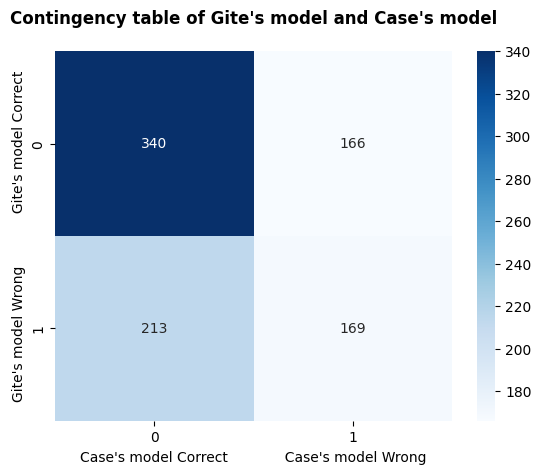

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Case's model Correct             Case's model Wrong")
plt.ylabel("Gite's model Wrong            Gite's model Correct")

title_font = {
    'fontsize': 12,
    'fontweight': 'bold'
}
plt.title("Contingency table of Gite's model and Case's model", fontdict=title_font, pad=20)
plt.show()

In [ ]:
# Perform McNemar test
result = mcnemar(contingency_table, exact=True)

print("\nMcNemar Test Results:")
print(f"Statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")


McNemar Test Results:
Statistic: 166.0
P-value: 0.018017707114693485


In [ ]:
# Interpretation of results
alpha = 0.05
if result.pvalue < alpha:
    print("\nThere is a significant difference.")
else:
    print("\nThere is no significant difference.")


There is a significant difference.


In [ ]:
# 2. Preparation of prediction results (Gite: Original (balanced data), Case: Original)
# Actual value
y_true = gite_data['ActualValue']

# Prediction results of Gite's Model
y_pred_model1 = gite_data['original_ms_today']

# Prediction results of Case's Model
y_pred_model2 = case_data['Number_Sent_Title']

In [ ]:
# Create confusion matrix
# Prediction correctness of the model
correct_model1 = y_pred_model1 == y_true
correct_model2 = y_pred_model2 == y_true

# 2x2 table for McNemar test (contingency table)
#                 Case's model
#                 correct  wrong
# Gite's model 1  correct  [a, b]
#                 wrong    [c, d]
a = np.sum(correct_model1 & correct_model2)  # both correct
b = np.sum(correct_model1 & ~correct_model2)  # only Gite's model correct
c = np.sum(~correct_model1 & correct_model2)  # only Case's model correct
d = np.sum(~correct_model1 & ~correct_model2)  # both wrong

contingency_table = np.array([[a, b], [c, d]])

print("Contingency Table:")
print(contingency_table)

Contingency Table:
[[360 146]
 [231 151]]


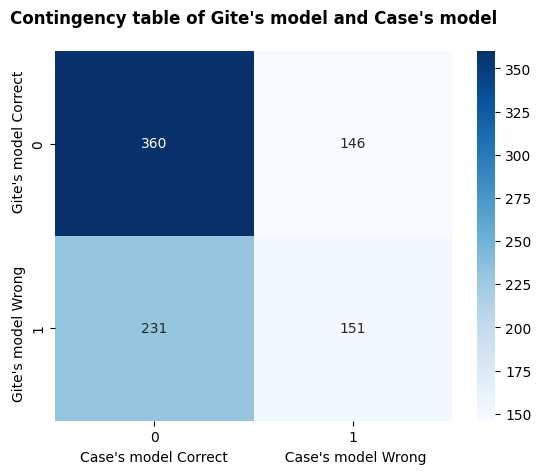

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(contingency_table, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Case's model Correct             Case's model Wrong")
plt.ylabel("Gite's model Wrong            Gite's model Correct")

title_font = {
    'fontsize': 12,
    'fontweight': 'bold'
}
plt.title("Contingency table of Gite's model and Case's model", fontdict=title_font, pad=20)
plt.show()

In [ ]:
# Perform McNemar test
result = mcnemar(contingency_table, exact=True)

print("\nMcNemar Test Results:")
print(f"Statistic: {result.statistic}")
print(f"P-value: {result.pvalue}")

# Interpretation of results
alpha = 0.05
if result.pvalue < alpha:
    print("\nThere is a significant difference.")
else:
    print("\nThere is no significant difference.")


McNemar Test Results:
Statistic: 146.0
P-value: 1.4024747200889024e-05

There is a significant difference.
